# Análisis Exploratorio de Datos (EDA) — 22 preguntas de selección múltiple

**Módulo:** Análisis Exploratorio de Datos  
**Tecnologías:** Python, Pandas, NumPy, Matplotlib y Seaborn  
**Tipo de actividad:** evaluación práctica con datos simulados  
**Número de preguntas:** 20

## Objetivo
Aplicar técnicas básicas de EDA para describir e interpretar un conjunto de datos, utilizando frecuencias, medidas de tendencia central y posición, visualizaciones, detección de valores atípicos, correlación y regresión lineal.

### Instrucciones
1. Ejecuta las celdas de código **en orden**.
2. Lee las tablas, estadísticos y gráficos que genera cada bloque antes de responder; las respuestas deben inferirse a partir del análisis.
3. Selecciona **una sola alternativa** por pregunta.
4. Las preguntas combinan interpretación y lectura de resultados; no dependen únicamente de memorizar sintaxis.
5. El dataset es simulado, pero está construido para representar un escenario académico razonable.
6. La semilla aleatoria se fija explícitamente en la primera celda para que los resultados sean **reproducibles**.

> **Importante:** si modificas la semilla, las respuestas numéricas de algunas preguntas cambiarán. Para esta versión, trabaja con la semilla indicada.


## 1. Importación de librerías y generación del dataset

El conjunto representa a **240 estudiantes**. Las variables describen edad, hábitos de estudio, asistencia, horas de sueño, puntaje previo y puntaje final.

El puntaje final se genera a partir de estas variables más un componente aleatorio. Se incorporan además cuatro observaciones extremas para que el análisis de valores atípicos sea más realista.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla explícita para garantizar reproducibilidad
SEED = 2026
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid")

n = 240

edad = rng.integers(18, 31, n)
horas_estudio = np.clip(rng.normal(5.8, 1.7, n), 1.0, 10.0)
asistencia_pct = np.clip(rng.normal(84, 8.5, n), 55, 100)
horas_sueno = np.clip(rng.normal(7.1, 0.8, n), 4.5, 9.5)
puntaje_previo = np.clip(rng.normal(64, 11, n), 30, 95)

puntaje_final = (
    5
    + 3.8 * horas_estudio
    + 0.25 * asistencia_pct
    + 1.3 * horas_sueno
    + 0.22 * puntaje_previo
    + rng.normal(0, 8, n)
)
puntaje_final = np.clip(puntaje_final, 0, 100)

# Cuatro observaciones extremas introducidas de manera deliberada
outlier_idx = [17, 88, 154, 219]
puntaje_final[outlier_idx] = [96, 94, 30, 35]

nivel = pd.cut(
    puntaje_final,
    bins=[0, 59.999, 69.999, 79.999, 89.999, 100],
    labels=["Insuficiente", "Suficiente", "Bueno", "Muy bueno", "Excelente"],
    include_lowest=True
)

df = pd.DataFrame({
    "id_estudiante": np.arange(1, n + 1),
    "edad": edad,
    "horas_estudio": horas_estudio.round(2),
    "asistencia_pct": asistencia_pct.round(1),
    "horas_sueno": horas_sueno.round(2),
    "puntaje_previo": puntaje_previo.round(1),
    "puntaje_final": puntaje_final.round(1),
    "nivel": nivel
})

print(f"Semilla utilizada: {SEED}")
print(f"Cantidad de estudiantes: {len(df)}")
df.head()

Semilla utilizada: 2026
Cantidad de estudiantes: 240


,id_estudiante,edad,horas_estudio,asistencia_pct,horas_sueno,puntaje_previo,puntaje_final,nivel
0,1,29,4.76,90.5,6.53,53.7,65.7,Suficiente
1,2,20,5.75,91.7,6.82,66.8,73.1,Bueno
2,3,18,8.63,99.8,6.12,37.0,66.2,Suficiente
3,4,26,3.93,74.6,7.75,51.9,66.5,Suficiente
4,5,22,7.10,86.2,7.82,56.8,65.3,Suficiente


## 2. Inspección inicial

Antes de analizar los resultados, revisaremos dimensiones, tipos de datos y posibles valores faltantes.

In [ ]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores faltantes por variable:")
print(df.isna().sum())

Dimensiones: (240, 8)

Tipos de datos:
id_estudiante        int64
edad                 int64
horas_estudio      float64
asistencia_pct     float64
horas_sueno        float64
puntaje_previo     float64
puntaje_final      float64
nivel             category
dtype: object

Valores faltantes por variable:
id_estudiante     0
edad              0
horas_estudio     0
asistencia_pct    0
horas_sueno       0
puntaje_previo    0
puntaje_final     0
nivel             0
dtype: int64


### Pregunta 1

¿Cuántos estudiantes pertenecen al nivel **Muy bueno** según la tabla de frecuencias?

- **A)** 42
- **B)** 48
- **C)** 54
- **D)** 61

In [ ]:
frecuencias = df["nivel"].value_counts().sort_index()
frecuencias

,count
nivel,
Insuficiente,40
Suficiente,71
Bueno,70
Muy bueno,48
Excelente,11


### Pregunta 2

A partir de la tabla de frecuencias obtenida para `nivel`, ¿qué medida permite identificar directamente qué categoría presenta la **mayor frecuencia absoluta**?

- **A)** La media.
- **B)** La moda.
- **C)** La mediana.
- **D)** El percentil 75.


In [ ]:
# Tabla de frecuencias para interpretar la categoría modal
frecuencias = df["nivel"].value_counts().sort_values(ascending=False)
frecuencias.to_frame(name="Frecuencia absoluta")


### Pregunta 3

¿Qué proporción aproximada de estudiantes tiene un `puntaje_final` **igual o superior a 80**?

- **A)** Entre 10% y 20%.
- **B)** Entre 20% y 30%.
- **C)** Entre 30% y 40%.
- **D)** Más del 50%.

In [ ]:
proporcion_80 = (df["puntaje_final"] >= 80).mean()
print(f"Proporción: {proporcion_80:.3f} ({proporcion_80:.1%})")

## 3. Medidas descriptivas

Ahora examinaremos medidas de tendencia central y posición del `puntaje_final`.

In [ ]:
df.describe()

,id_estudiante,edad,horas_estudio,asistencia_pct,horas_sueno,puntaje_previo,puntaje_final
count,240.00000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,120.50000,23.987500,5.885875,84.088750,7.099708,63.970833,70.894167
std,69.42622,3.647067,1.760810,8.624932,0.766223,11.144185,11.566528
min,1.00000,18.000000,1.000000,57.600000,4.790000,35.500000,30.000000
25%,60.75000,21.000000,4.680000,77.550000,6.617500,56.650000,62.975000
50%,120.50000,24.000000,5.920000,84.850000,7.085000,64.100000,71.200000
75%,180.25000,27.000000,7.082500,90.200000,7.622500,71.725000,79.700000
max,240.00000,30.000000,10.000000,100.000000,8.980000,90.900000,100.000000


### Pregunta 4

Si se desea una medida de tendencia central **menos sensible a los valores extremos**, ¿cuál es la alternativa más apropiada?

- **A)** Media aritmética.
- **B)** Mediana.
- **C)** Varianza.
- **D)** Rango.

### Pregunta 5

La distribución de `puntaje_final` presenta una forma aproximadamente **simétrica** y no se observan valores extremos que dominen el comportamiento de los datos. ¿Qué medida de tendencia central sería, en principio, la más apropiada para representar el centro de la distribución?

- **A)** La media aritmética.
- **B)** La mediana.
- **C)** El rango.
- **D)** El máximo.


In [ ]:
# Estadísticos descriptivos del puntaje final
df[["puntaje_final"]].describe()


,puntaje_final
count,240.000000
mean,70.894167
std,11.566528
min,30.000000
25%,62.975000
50%,71.200000
75%,79.700000
max,100.000000


### Pregunta 6

Al comparar la media y la mediana, ¿qué interpretación es más adecuada?

- **A)** Si son diferentes, necesariamente existe un error en los datos.
- **B)** La diferencia puede aportar información sobre asimetría o influencia de valores extremos.
- **C)** La mediana siempre debe ser mayor que la media.
- **D)** Ambas medidas representan la frecuencia absoluta.

### Pregunta 7

El tercer cuartil (**Q3**) del `puntaje_final` es aproximadamente **79,7**. ¿Cuál es la interpretación correcta?

- **A)** Aproximadamente el 25% de los estudiantes tiene puntajes menores o iguales a Q3.
- **B)** Aproximadamente el 50% de los estudiantes tiene puntajes menores o iguales a Q3.
- **C)** Aproximadamente el 75% de los estudiantes tiene puntajes menores o iguales a Q3.
- **D)** El 75% de los estudiantes obtuvo exactamente 79,7.

In [ ]:
cuartiles = df["puntaje_final"].quantile([0.25, 0.50, 0.75])
cuartiles

### Pregunta 8

El percentil 70 (**P70**) del `puntaje_final` es aproximadamente **77,2**. ¿Qué significa?

- **A)** Aproximadamente el 70% de los estudiantes tiene un puntaje menor o igual a ese valor.
- **B)** Exactamente el 70% de los estudiantes obtuvo ese puntaje.
- **C)** Aproximadamente el 30% de los estudiantes tiene un puntaje menor o igual a ese valor.
- **D)** P70 es necesariamente igual a Q3.

In [ ]:
p70 = df["puntaje_final"].quantile(0.70)
print(f"P70 = {p70:.2f}")

P70 = 77.13


### Pregunta 9

¿Cuál afirmación describe correctamente la relación entre **correlación y causalidad**?

- **A)** Una correlación alta demuestra que una variable causa cambios en la otra.
- **B)** Si dos variables están correlacionadas, siempre existe una relación causal entre ellas.
- **C)** La correlación indica asociación entre variables, pero por sí sola no permite concluir causalidad.
- **D)** La causalidad solo puede existir cuando la correlación es exactamente 1.


In [ ]:
quintiles = df["puntaje_final"].quantile([0.2, 0.4, 0.6, 0.8])
quintiles

## 4. Visualización de datos

Los gráficos permiten identificar concentración, dispersión, asimetría y posibles observaciones inusuales.

### Pregunta 10

En un análisis exploratorio se desea detectar posibles **valores atípicos** de una variable cuantitativa mediante el criterio del rango intercuartílico (IQR). ¿Cuál regla es correcta?

- **A)** Son atípicos los valores menores que Q1 − 1,5·IQR o mayores que Q3 + 1,5·IQR.
- **B)** Son atípicos todos los valores menores que la media.
- **C)** Son atípicos los valores que se encuentran a más de 1,5 unidades de la mediana.
- **D)** Son atípicos únicamente los valores iguales al mínimo o al máximo.


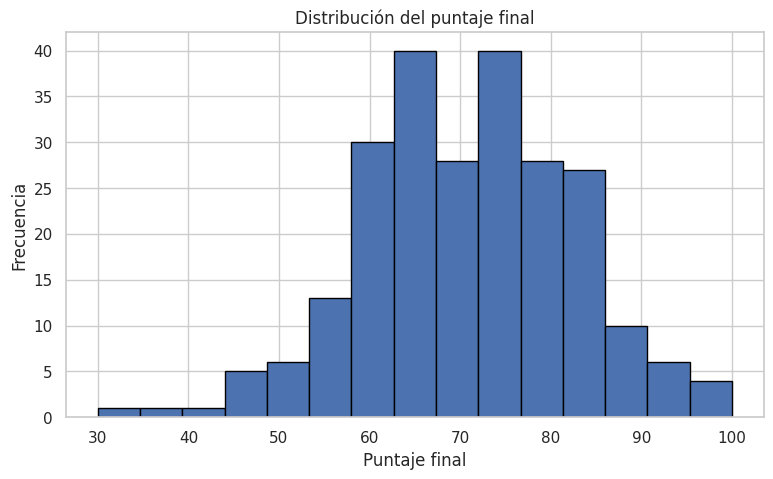

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df["puntaje_final"], bins=15, edgecolor="black")
plt.title("Distribución del puntaje final")
plt.xlabel("Puntaje final")
plt.ylabel("Frecuencia")
plt.show()

### Pregunta 11

Se desea estudiar la relación entre `horas_estudio` y `puntaje_final`. El análisis muestra una correlación positiva. ¿Cuál conclusión es **estadísticamente apropiada**?

- **A)** Estudiar más horas necesariamente causa un aumento del puntaje.
- **B)** Existe una asociación positiva entre ambas variables, pero la correlación por sí sola no demuestra causalidad.
- **C)** El 100% de los estudiantes que estudian más obtiene un mayor puntaje.
- **D)** Las dos variables son independientes.


### Pregunta 12

Utilizando la regla del rango intercuartílico (IQR), se consideran atípicos los valores menores que `Q1 − 1.5·IQR` o mayores que `Q3 + 1.5·IQR`. ¿Cuántos puntos atípicos se detectan?

- **A)** 0
- **B)** 1
- **C)** 2
- **D)** 4

In [ ]:
Q1 = df["puntaje_final"].quantile(0.25)
Q3 = df["puntaje_final"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos = df[
    (df["puntaje_final"] < limite_inferior)
    | (df["puntaje_final"] > limite_superior)
]

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Límite inferior = {limite_inferior:.2f}")
print(f"Límite superior = {limite_superior:.2f}")
print(f"Cantidad de atípicos = {len(atipicos)}")

atipicos[["id_estudiante", "puntaje_final"]]

Q1 = 62.98
Q3 = 79.70
IQR = 16.73
Límite inferior = 37.89
Límite superior = 104.79
Cantidad de atípicos = 2


,id_estudiante,puntaje_final
154,155,30.0
219,220,35.0


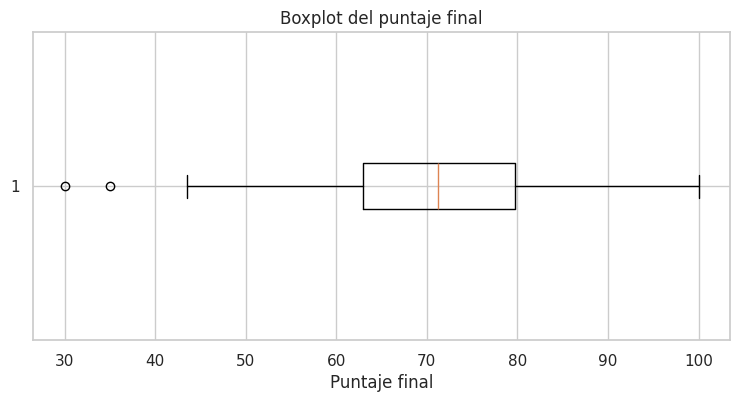

In [ ]:
plt.figure(figsize=(9, 4))
plt.boxplot(df["puntaje_final"], vert=False)
plt.title("Boxplot del puntaje final")
plt.xlabel("Puntaje final")
plt.show()

## 5. Correlación

La correlación de Pearson permite cuantificar la intensidad y dirección de una **relación lineal** entre dos variables cuantitativas.

### Pregunta 13

¿Cuál de las siguientes variables presenta la correlación lineal más fuerte, en valor absoluto, con `puntaje_final`?

- **A)** Edad.
- **B)** Horas de sueño.
- **C)** Horas de estudio.
- **D)** Puntaje previo.

In [ ]:
vars_num = [
    "edad", "horas_estudio", "asistencia_pct",
    "horas_sueno", "puntaje_previo", "puntaje_final"
]
matriz_corr = df[vars_num].corr()
matriz_corr

,edad,horas_estudio,asistencia_pct,horas_sueno,puntaje_previo,puntaje_final
edad,1.000000,-0.052894,-0.069651,-0.057317,-0.040580,0.026779
horas_estudio,-0.052894,1.000000,0.041737,-0.035768,0.067601,0.573522
asistencia_pct,-0.069651,0.041737,1.000000,-0.089328,-0.004775,0.249443
horas_sueno,-0.057317,-0.035768,-0.089328,1.000000,0.011481,0.045639
puntaje_previo,-0.040580,0.067601,-0.004775,0.011481,1.000000,0.285109
puntaje_final,0.026779,0.573522,0.249443,0.045639,0.285109,1.000000


### Pregunta 14

La correlación entre `horas_estudio` y `puntaje_final` es aproximadamente **0,57**. ¿Cuál interpretación es la más adecuada?

- **A)** Existe una asociación lineal positiva de magnitud moderada: mayores horas de estudio tienden a asociarse con mayores puntajes.
- **B)** Existe una relación negativa perfecta.
- **C)** El valor 0,57 demuestra que estudiar causa el aumento del puntaje.
- **D)** Una correlación de 0,57 significa que el 57% de los estudiantes estudia más de 5 horas.

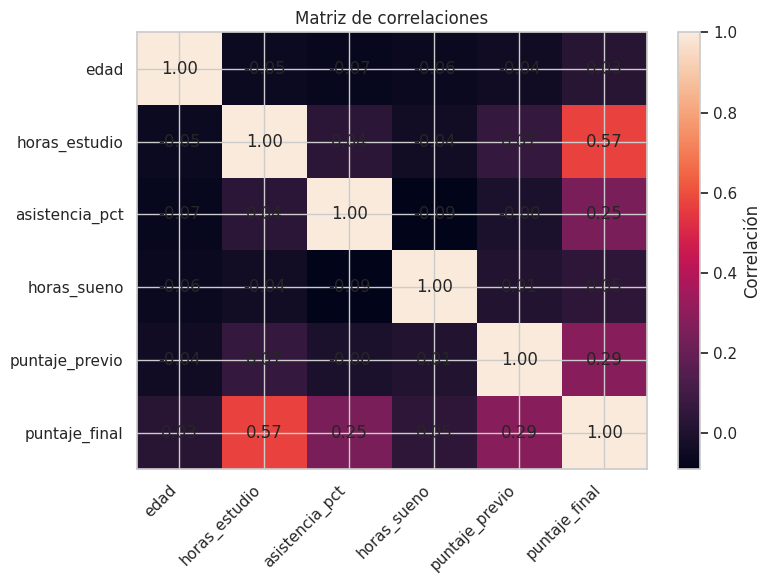

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(matriz_corr, aspect="auto")
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(matriz_corr.index)), matriz_corr.index)
plt.colorbar(label="Correlación")
for i in range(len(matriz_corr.index)):
    for j in range(len(matriz_corr.columns)):
        plt.text(j, i, f"{matriz_corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

### Pregunta 15

¿Cuál afirmación es correcta respecto de la correlación de Pearson?

- **A)** Una correlación alta demuestra causalidad.
- **B)** Una correlación cercana a 0 implica necesariamente independencia estadística.
- **C)** La correlación cuantifica asociación lineal y toma valores entre -1 y 1.
- **D)** La correlación solo puede tomar valores positivos.

## 6. Regresión lineal simple

Se modelará `puntaje_final` en función de `horas_estudio` mediante:

$$Y = \beta_0 + \beta_1X + \varepsilon$$

Los coeficientes se estiman mediante mínimos cuadrados con `numpy.linalg.lstsq`.

### Pregunta 16

La pendiente estimada de la regresión simple es aproximadamente **3,77**. ¿Qué representa?

- **A)** El puntaje esperado cuando las horas de estudio son 0.
- **B)** El aumento esperado del puntaje final, en promedio, por cada hora adicional de estudio, según el modelo.
- **C)** La correlación entre horas de estudio y puntaje final.
- **D)** El porcentaje de estudiantes que aprueba.

In [ ]:
X = np.column_stack([np.ones(len(df)), df["horas_estudio"].to_numpy()])
y = df["puntaje_final"].to_numpy()

coef = np.linalg.lstsq(X, y, rcond=None)[0]
intercepto, pendiente = coef

y_pred = X @ coef
R2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Intercepto = {intercepto:.2f}")
print(f"Pendiente = {pendiente:.2f}")
print(f"R² = {R2:.3f}")

Intercepto = 48.72
Pendiente = 3.77
R² = 0.329


### Pregunta 17

El R² de la regresión simple es aproximadamente **0,33**. ¿Qué significa conceptualmente?

- **A)** Aproximadamente el 33% de la variabilidad observada del puntaje final queda explicada por `horas_estudio` en este modelo lineal.
- **B)** Existe un 33% de probabilidad de aprobar.
- **C)** El modelo demuestra que el 33% de los estudiantes estudia más.
- **D)** R² es exactamente igual a la pendiente.

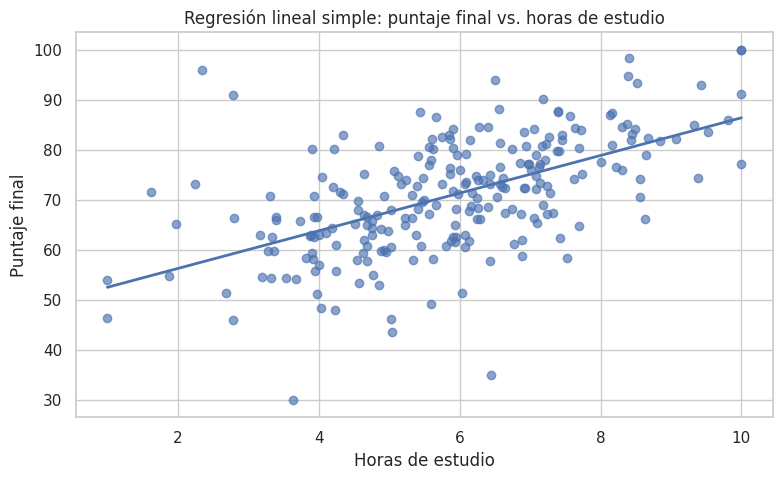

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(df["horas_estudio"], df["puntaje_final"], alpha=0.65)
orden = np.argsort(df["horas_estudio"].to_numpy())
plt.plot(
    df["horas_estudio"].to_numpy()[orden],
    y_pred[orden],
    linewidth=2
)
plt.title("Regresión lineal simple: puntaje final vs. horas de estudio")
plt.xlabel("Horas de estudio")
plt.ylabel("Puntaje final")
plt.show()

## 7. Regresión lineal múltiple

Ahora se utilizarán simultáneamente cuatro variables explicativas:

- `horas_estudio`
- `asistencia_pct`
- `horas_sueno`
- `puntaje_previo`

El objetivo es analizar el aporte de cada predictor **considerando los demás predictores incluidos en el modelo**.

### Pregunta 18

¿Cuál es la principal diferencia entre la regresión lineal simple y la múltiple?

- **A)** La regresión simple utiliza una respuesta categórica y la múltiple una respuesta cuantitativa.
- **B)** La regresión simple utiliza un predictor, mientras que la múltiple utiliza dos o más predictores.
- **C)** La regresión múltiple no permite estimar coeficientes.
- **D)** La regresión simple siempre presenta un R² mayor.

In [ ]:
predictores = [
    "horas_estudio", "asistencia_pct",
    "horas_sueno", "puntaje_previo"
]

X = np.column_stack(
    [np.ones(len(df))] + [df[c].to_numpy() for c in predictores]
)
y = df["puntaje_final"].to_numpy()

coef_multiple = np.linalg.lstsq(X, y, rcond=None)[0]
y_pred_multiple = X @ coef_multiple

R2_multiple = 1 - (
    np.sum((y - y_pred_multiple) ** 2)
    / np.sum((y - y.mean()) ** 2)
)

tabla_coef = pd.DataFrame({
    "Variable": ["Intercepto"] + predictores,
    "Coeficiente": coef_multiple
})

display(tabla_coef)
print(f"R² del modelo múltiple = {R2_multiple:.3f}")

,Variable,Coeficiente
0,Intercepto,-2.300698
1,horas_estudio,3.612364
2,asistencia_pct,0.315324
3,horas_sueno,1.259934
4,puntaje_previo,0.257501


R² del modelo múltiple = 0.449


### Pregunta 19

En la regresión múltiple, si el coeficiente de `horas_estudio` es positivo, ¿cuál es la interpretación más adecuada?

- **A)** Por cada hora adicional de estudio, el puntaje aumenta exactamente esa cantidad, independientemente de las demás variables.
- **B)** Manteniendo constantes las otras variables del modelo, una hora adicional de estudio se asocia con un aumento esperado del puntaje igual al coeficiente estimado.
- **C)** El coeficiente es la correlación entre todas las variables.
- **D)** El coeficiente demuestra por sí solo una relación causal.

### Pregunta 20

Al comparar el R² de un modelo simple con el R² de un modelo múltiple que contiene el predictor del modelo simple **más variables adicionales**, ambos estimados sobre los mismos datos, ¿qué afirmación es correcta?

- **A)** El R² del modelo múltiple no puede ser menor que el R² del modelo simple.
- **B)** El R² del modelo múltiple siempre debe ser igual a 1.
- **C)** El R² no depende de las variables incluidas.
- **D)** El R² disminuye obligatoriamente al agregar predictores.

In [ ]:
comparacion = pd.DataFrame({
    "Modelo": ["Simple", "Múltiple"],
    "R2": [R2, R2_multiple]
})
comparacion

,Modelo,R2
0,Simple,0.328927
1,Múltiple,0.448588


## 8. Solucionario para el docente

> **Nota:** elimina esta sección antes de entregar el notebook a estudiantes si no quieres revelar las respuestas.

| Pregunta | Respuesta | Fundamento |
|---:|:---:|---|
| 1 | **B** | La frecuencia de **Muy bueno** es 48 estudiantes. |
| 2 | **B** | La moda corresponde a la categoría con mayor frecuencia absoluta; se identifica directamente en la tabla de frecuencias. |
| 3 | **B** | La proporción con puntaje ≥ 80 es aproximadamente 24,6%. |
| 4 | **B** | La mediana es menos sensible a valores extremos que la media. |
| 5 | **A** | Cuando una distribución es aproximadamente simétrica y no está dominada por valores extremos, la media es una medida apropiada para representar el centro. |
| 6 | **B** | Diferencias entre media y mediana pueden aportar información sobre asimetría o valores extremos. |
| 7 | **C** | Q3 corresponde al percentil 75: aproximadamente 75% de los datos queda por debajo o igual. |
| 8 | **A** | P70 deja aproximadamente 70% de las observaciones por debajo o igual. |
| 9 | **C** | La correlación describe asociación; por sí sola no permite establecer una relación causal. |
| 10 | **A** | El criterio 1,5·IQR considera atípicos los valores fuera de los límites Q1 − 1,5·IQR y Q3 + 1,5·IQR. |
| 11 | **B** | Una correlación positiva indica asociación lineal positiva, pero no demuestra causalidad por sí sola. |
| 12 | **C** | La regla 1,5·IQR identifica 2 observaciones atípicas en este dataset. |
| 13 | **C** | `horas_estudio` presenta la mayor correlación absoluta con `puntaje_final`. |
| 14 | **A** | r ≈ 0,57 indica asociación lineal positiva de magnitud moderada; no demuestra causalidad. |
| 15 | **C** | Pearson mide asociación lineal y toma valores entre -1 y 1. |
| 16 | **B** | La pendiente ≈ 3,77 representa el cambio esperado del puntaje por una hora adicional de estudio en el modelo simple. |
| 17 | **A** | R² ≈ 0,33 indica la proporción de variabilidad explicada por el modelo simple. |
| 18 | **B** | La regresión simple tiene un predictor; la múltiple tiene dos o más. |
| 19 | **B** | En el modelo múltiple, la interpretación del coeficiente es condicional a los demás predictores. |
| 20 | **A** | Al agregar predictores al modelo y estimar sobre los mismos datos, el R² ordinario no disminuye. |

## 9. Extensión opcional

Para profundizar el análisis, se puede pedir al estudiante que:

1. Calcule la desviación estándar y el coeficiente de variación del `puntaje_final`.
2. Compare media y mediana antes y después de retirar los puntos atípicos.
3. Analice la relación entre `asistencia_pct` y `puntaje_final`.
4. Compare las correlaciones antes y después de retirar los puntos atípicos.
5. Compare el R² simple y múltiple y explique por qué cambia.


In [ ]:
df.head()

,id_estudiante,edad,horas_estudio,asistencia_pct,horas_sueno,puntaje_previo,puntaje_final,nivel
0,1,29,4.76,90.5,6.53,53.7,65.7,Suficiente
1,2,20,5.75,91.7,6.82,66.8,73.1,Bueno
2,3,18,8.63,99.8,6.12,37.0,66.2,Suficiente
3,4,26,3.93,74.6,7.75,51.9,66.5,Suficiente
4,5,22,7.10,86.2,7.82,56.8,65.3,Suficiente


### Pregunta extra 1

Si quisieras representar la distribución porcentaje de asistencia según el nivel de rendimiento ¿Qué gráfico sería el más apropiado?

- **A)** histograma
- **B)** boxplot
- **C)** gráfico de barras
- **D)** gráfico de líneas

### Pregunta extra 2

¿Qué gráfico representa mejor la frecuencia de estudiantes según el nivel de rendimiento, considerando que esta variable es cualitativa ordinal?

- **A)** histograma
- **B)** boxplot
- **C)** gráfico de barras
- **D)** gráfico circular